# Part 1d: Monte Carlo Dropout
**Author:** Kalhar Mayurbhai Patel (019140511)

MC Dropout keeps dropout active at inference time. By running multiple forward passes,
we get a distribution of predictions — giving us **uncertainty estimates**.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## TensorFlow: MC Dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TF MC Dropout — Mean acc: 0.9600
Avg uncertainty (std): 0.0498


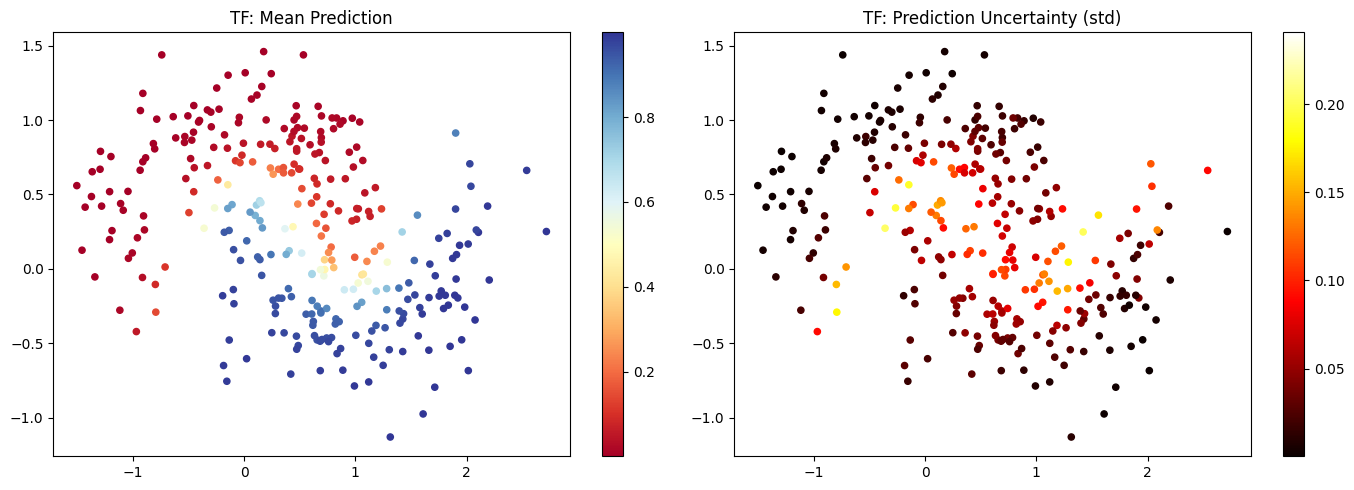

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

class MCDropout(layers.Dropout):
    """Dropout layer that stays active during inference."""
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)  # Always drop

model_tf = Sequential([
    layers.Dense(64, activation='relu', input_shape=(2,)),
    MCDropout(0.3),
    layers.Dense(32, activation='relu'),
    MCDropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_tf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tf.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# MC Dropout inference: run 100 forward passes
n_samples = 100
mc_preds = np.stack([model_tf(X_test, training=True).numpy().flatten() for _ in range(n_samples)])
mean_pred = mc_preds.mean(axis=0)
std_pred = mc_preds.std(axis=0)

print(f"TF MC Dropout — Mean acc: {((mean_pred > 0.5).astype(int) == y_test).mean():.4f}")
print(f"Avg uncertainty (std): {std_pred.mean():.4f}")

# Visualize uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_test[:, 0], X_test[:, 1], c=mean_pred, cmap='RdYlBu', s=20)
axes[0].set_title('TF: Mean Prediction'); plt.colorbar(scatter, ax=axes[0])
scatter2 = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=std_pred, cmap='hot', s=20)
axes[1].set_title('TF: Prediction Uncertainty (std)'); plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout(); plt.show()

## PyTorch: MC Dropout

PT MC Dropout — Mean acc: 0.8900
Avg uncertainty: 0.0706


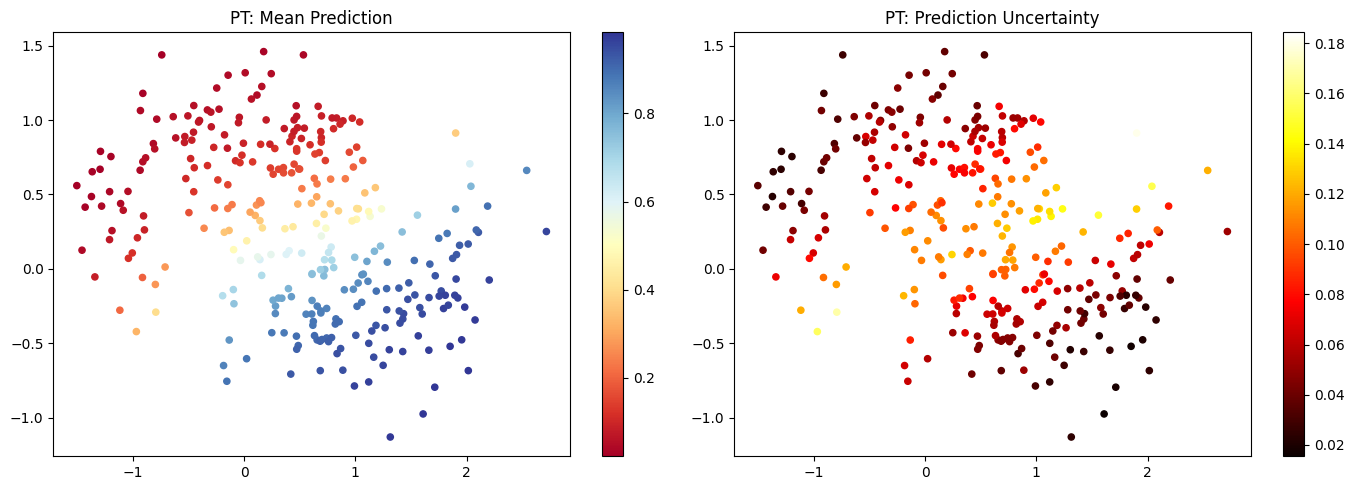

In [3]:
import torch, torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MCDropoutNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.drop = nn.Dropout(0.3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))
        return torch.sigmoid(self.fc3(x))

torch.manual_seed(42)
model_pt = MCDropoutNet().to(device)
opt = torch.optim.Adam(model_pt.parameters())
crit = nn.BCELoss()
X_tr = torch.FloatTensor(X_train).to(device)
y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)

for ep in range(100):
    model_pt.train()
    opt.zero_grad()
    crit(model_pt(X_tr), y_tr).backward()
    opt.step()

# MC Dropout: keep model in TRAIN mode for dropout
model_pt.train()  # Keep dropout active!
X_te = torch.FloatTensor(X_test).to(device)
mc_preds_pt = torch.stack([model_pt(X_te).squeeze() for _ in range(100)])
mean_pt = mc_preds_pt.mean(dim=0).detach().cpu().numpy()
std_pt = mc_preds_pt.std(dim=0).detach().cpu().numpy()

print(f"PT MC Dropout — Mean acc: {((mean_pt > 0.5).astype(int) == y_test).mean():.4f}")
print(f"Avg uncertainty: {std_pt.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
s1 = axes[0].scatter(X_test[:, 0], X_test[:, 1], c=mean_pt, cmap='RdYlBu', s=20)
axes[0].set_title('PT: Mean Prediction'); plt.colorbar(s1, ax=axes[0])
s2 = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=std_pt, cmap='hot', s=20)
axes[1].set_title('PT: Prediction Uncertainty'); plt.colorbar(s2, ax=axes[1])
plt.tight_layout(); plt.show()

## Why MC Dropout Matters
- Standard models give point predictions — no notion of confidence
- MC Dropout provides **epistemic uncertainty** at zero extra cost
- Points near the decision boundary show higher uncertainty (std)
- Useful for safety-critical applications: flag uncertain predictions for human review